# LSTM Model

In [30]:
# Install needed libraries
# %pip install spacy wordcloud lime optuna tabulate
# !python -m spacy download en_core_web_sm

In [1]:
# Handle all imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import re
import spacy
import random
from collections import Counter
import os
import json
import time
import urllib.request
import zipfile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import torch.optim as optim

from sklearn.model_selection import train_test_split
import optuna

# Shared project helpers.
import analysis_utils as au
import IPython.core.display, IPython.display
IPython.core.display.display = IPython.display.display
from sklearn.feature_extraction.text import CountVectorizer

print(f"torch {torch.__version__} | optuna {optuna.__version__}")

torch 2.12.0 | optuna 4.9.0


/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Define all constants

# General constants
INPUT_FILE_NAME = 'yelp_sentiments.csv'
RAND_STATE = 498

# Number of samples in training set.
SAMPLE_SIZE = 72000
USE_PACKING = True

# Data constants
TEST_SPLIT = 0.20
VAL_SPLIT = 0.10
VOCAB_SIZE = 20000
EMBED_DIM = 100

# Training constants
EPOCHS = 10
BATCH_SIZE = 256
MAX_LENGTH = 256 # match distilBERT

# HPO constants
N_TRIALS = 10
HPO_EPOCHS = 10
OBJECTIVE_METRIC = 'f1_macro'
HPO_VERBOSITY = 'epoch'

CLASS_NAMES = au.CLASS_NAMES
CLASS_IDS = au.CLASS_IDS
CLASS_COLORS = au.CLASS_COLORS
CLASS_CMAPS = au.CLASS_CMAPS
LOG_EVERY = 20

# LIME constants
N_PER_CLASS = 30
NUM_SAMPLES = 800
NUM_FEATURES = 25
MIN_OBS = 5

In [3]:
# Handles contractions with apostrophes
CONTRACTIONS_APOS = [
    (re.compile(r"\bcan['\u2019]t\b",   re.I), "can not"),
    (re.compile(r"\bwon['\u2019]t\b",   re.I), "will not"),
    (re.compile(r"\bshan['\u2019]t\b",  re.I), "shall not"),
    (re.compile(r"\bain['\u2019]t\b",   re.I), "is not"),
    (re.compile(r"n['\u2019]t\b",       re.I), " not"),
    (re.compile(r"['\u2019]re\b",       re.I), " are"),
    (re.compile(r"['\u2019]ve\b",       re.I), " have"),
    (re.compile(r"['\u2019]ll\b",       re.I), " will"),
    (re.compile(r"['\u2019]m\b",        re.I), " am"),
]

# Handle contractions written without an apostrophe
CONTRACTIONS_BARE = [
    (re.compile(r"\b%s\b" % pat, re.I), rep) for pat, rep in [
        ("cant", "can not"),       ("wont", "will not"),
        ("dont", "do not"),        ("doesnt", "does not"),
        ("didnt", "did not"),      ("isnt", "is not"),
        ("wasnt", "was not"),      ("arent", "are not"),
        ("werent", "were not"),    ("couldnt", "could not"),
        ("wouldnt", "would not"),  ("shouldnt", "should not"),
        ("havent", "have not"),    ("hasnt", "has not"),
        ("hadnt", "had not"),      ("aint", "is not"),
    ]
]

In [ ]:
# Model configurations
OUTPUT_DIM = 3

# Baseline constants
BASELINE_LR = 1e-3
BASELINE_WEIGHT_DECAY = 1e-6
BASELINE_HIDDEN_DIM = 128
BASELINE_NUM_LAYERS = 1
BASELINE_BIDIRECTIONAL = False
BASELINE_LSTM_DROPOUT = 0.0  # Only 1 layer, so dropout is not applied
BASELINE_FC_LAYERS = 1
BASELINE_FC_DIM = 128
BASELINE_FC_DROPOUT = 0.2
BASELINE_BATCH_SIZE = 256
BASELINE_FREEZE_EMBEDDINGS = True

# Optimized constants
OPTIMIZED_LR = 0.004084
OPTIMIZED_WEIGHT_DECAY = 2e-05
OPTIMIZED_HIDDEN_DIM = 128
OPTIMIZED_NUM_LAYERS = 2
OPTIMIZED_BIDIRECTIONAL = True
OPTIMIZED_LSTM_DROPOUT = 0.259646
OPTIMIZED_FC_LAYERS = 2
OPTIMIZED_FC_DIM = 64
OPTIMIZED_FC_DROPOUT = 0.190272
OPTIMIZED_BATCH_SIZE = 256
OPTIMIZED_FREEZE_EMBEDDINGS = True

# Baseline config, used as trial 0 for comparison.
BASELINE_CONFIG = {
    'lr': BASELINE_LR,
    'weight_decay': BASELINE_WEIGHT_DECAY,
    'hidden_dim': BASELINE_HIDDEN_DIM,
    'num_layers': BASELINE_NUM_LAYERS,
    'bidirectional': BASELINE_BIDIRECTIONAL,
    'lstm_dropout': BASELINE_LSTM_DROPOUT,
    'fc_layers': BASELINE_FC_LAYERS,
    'fc_dim': BASELINE_FC_DIM,
    'fc_dropout': BASELINE_FC_DROPOUT,
    'batch_size': BASELINE_BATCH_SIZE,
    'freeze_embeddings': BASELINE_FREEZE_EMBEDDINGS,
}

# Best config from previous trials
OPTIMIZED_CONFIG = {
    'lr': OPTIMIZED_LR,
    'weight_decay': OPTIMIZED_WEIGHT_DECAY,
    'hidden_dim': OPTIMIZED_HIDDEN_DIM,
    'num_layers': OPTIMIZED_NUM_LAYERS,
    'bidirectional': OPTIMIZED_BIDIRECTIONAL,
    'lstm_dropout': OPTIMIZED_LSTM_DROPOUT,
    'fc_layers': OPTIMIZED_FC_LAYERS,
    'fc_dim': OPTIMIZED_FC_DIM,
    'fc_dropout': OPTIMIZED_FC_DROPOUT,
    'batch_size': OPTIMIZED_BATCH_SIZE,
    'freeze_embeddings': OPTIMIZED_FREEZE_EMBEDDINGS,
}

FINAL_CONFIG = OPTIMIZED_CONFIG
USE_STUDY_BEST = False

print("Final configuration:", FINAL_CONFIG)

Final configuration: {'lr': 0.004084, 'weight_decay': 2e-05, 'hidden_dim': 128, 'num_layers': 2, 'bidirectional': True, 'lstm_dropout': 0.259646, 'fc_layers': 2, 'fc_dim': 64, 'fc_dropout': 0.190272, 'batch_size': 256, 'freeze_embeddings': True}


In [8]:
# Optuna constants
SEARCH_SPACE = {
    'lr':                ('float_log',   1e-4, 1e-2),
    'weight_decay':      ('float_log',   1e-6, 1e-3),
    'hidden_dim':        ('categorical', [64, 128, 256]),
    'num_layers':        ('int',         1, 2),
    'bidirectional':     ('categorical', [False, True]),
    'lstm_dropout':      ('float',       0.1, 0.3),
    'fc_dim':            ('categorical', [64, 128]),
    'fc_dropout':        ('float',       0.1, 0.3),
    'fc_layers':         ('categorical', [1, 2]),
    'batch_size':        ('categorical', [64, 128, 256]),
    'freeze_embeddings': ('categorical', [True, False]),
}

# Plants baseline and previous best configurations for comparison
WARM_START_CONFIGS = [BASELINE_CONFIG, OPTIMIZED_CONFIG]

In [34]:
# Check if GPU is available via Cuda or MPS (Mac)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: mps


In [35]:
# Set global seeding to ensure reproducibility
def set_seed(seed=RAND_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # Guard device-specific calls so this does not error on machines without them.
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        try:
            torch.mps.manual_seed(seed)
        except Exception:
            pass
    # Prevents non-deterministic CUDA ops
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

Define an appropriate architecture, considering embedding layers, hidden units, and regularization layers. 

In [36]:
# Read the data in as pandas dataframe
df = pd.read_csv(INPUT_FILE_NAME)
df.head()

,text,sentiment,text_len
0,I was glad that I was able to find a korean re...,2,289
1,Bloomsday is the quintessential Philly spot; F...,3,335
2,"What can I say.. It's Indian food, definitely...",2,176
3,The best!\n\nThe Bismarck is the best I have e...,3,265
4,Over all my experience would have been amazing...,2,1598


In [37]:
# Split by feature and label
X = df['text']
y = df['sentiment']

# CrossEntropyLoss requires 0-indexed, contiguous class ids (0..C-1)
label2id = {lab: idx for idx, lab in enumerate(sorted(y.unique()))}
id2label = {idx: lab for lab, idx in label2id.items()}
y = y.map(label2id)
print("Label remap (raw -> id):", label2id)   # expect {1: 0, 2: 1, 3: 2}

print("Class id -> name -> raw label")
for i, name in zip(CLASS_IDS, CLASS_NAMES):
    print(f"  {i} -> {name:<8} -> raw {id2label[i]}")

Label remap (raw -> id): {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}
Class id -> name -> raw label
  0 -> Negative -> raw 1
  1 -> Neutral  -> raw 2
  2 -> Positive -> raw 3


In [38]:
# Three-way split: 72% train / 8% validation / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=RAND_STATE)

# Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=VAL_SPLIT, stratify=y_temp, random_state=RAND_STATE)

# Subsampling since full dataset is too large.
if SAMPLE_SIZE is not None:
    frac = min(1.0, SAMPLE_SIZE / len(X_train))
    n_val  = max(1, int(len(X_val) * frac))
    n_test = max(1, int(len(X_test) * frac))
    X_train, y_train = X_train.iloc[:SAMPLE_SIZE], y_train.iloc[:SAMPLE_SIZE]
    X_val,   y_val   = X_val.iloc[:n_val],         y_val.iloc[:n_val]
    X_test,  y_test  = X_test.iloc[:n_test],       y_test.iloc[:n_test]
    print(f"[SAMPLE_SIZE={SAMPLE_SIZE}] subsampled to {frac:.1%} of each split")

total = len(X_train) + len(X_val) + len(X_test)
print(f"Train      : {len(X_train):>7,} rows ({len(X_train)/total:.1%})")
print(f"Validation : {len(X_val):>7,} rows ({len(X_val)/total:.1%})")
print(f"Test       : {len(X_test):>7,} rows ({len(X_test)/total:.1%})  <- held out")

[SAMPLE_SIZE=72000] subsampled to 5.9% of each split
Train      :  72,000 rows (72.0%)
Validation :   8,000 rows (8.0%)
Test       :  20,000 rows (20.0%)  <- held out


In [39]:
# Confirm stratification held across all three splits.
counts = pd.DataFrame({
    'Train':      y_train.value_counts().sort_index(),
    'Validation': y_val.value_counts().sort_index(),
    'Test':       y_test.value_counts().sort_index(),
})
counts.index = [CLASS_NAMES[i] for i in counts.index]
display(counts)
display((counts / counts.sum()).round(4).rename(columns=lambda c: c + ' %'))

,Train,Validation,Test
Negative,23856,2622,6767
Neutral,23966,2660,6656
Positive,24178,2718,6577


,Train %,Validation %,Test %
Negative,0.3313,0.3278,0.3384
Neutral,0.3329,0.3325,0.3328
Positive,0.3358,0.3398,0.3288


In [ ]:
# Cleaning and tokenization (negation-aware)
nlp = spacy.load("en_core_web_sm")

def clean_and_tokenize(text):
    # Remove HTML entities (e.g. &nbsp;) and escape sequences (\n, \t)
    text = re.sub(r'&[a-z]+;', ' ', text)
    text = re.sub(r'[\n\r\t]+', ' ', text)

    # Expand contractions first, while the apostrophes still exist.
    for pattern, replacement in CONTRACTIONS_APOS:
        text = pattern.sub(replacement, text)
    for pattern, replacement in CONTRACTIONS_BARE:
        text = pattern.sub(replacement, text)

    # Drop irrelevant characters
    text = re.sub(r'[^a-zA-Z0-9\s!?.,]', '', text)

    # Tokenize using spacy
    tokens = [token.text.lower() for token in nlp.tokenizer(text) if not token.is_space]
    return tokens

In [41]:
# Tokenize all three splits
print("Tokenizing training X...")
X_train_tokens = [clean_and_tokenize(text) for text in X_train]

print("Tokenizing validation X...")
X_val_tokens = [clean_and_tokenize(text) for text in X_val]

print("Tokenizing testing X...")
X_test_tokens = [clean_and_tokenize(text) for text in X_test]

print(f"Done: {len(X_train_tokens):,} train / {len(X_val_tokens):,} val / "
      f"{len(X_test_tokens):,} test")

Tokenizing training X...
Tokenizing validation X...
Tokenizing testing X...
Done: 72,000 train / 8,000 val / 20,000 test


In [42]:
# Build a frequency counter for tokens
counter = Counter()
for tokens in X_train_tokens:
    counter.update(tokens)

# Build vocabulary dictionary (word -> integer index)
word2idx = {'<pad>': 0, '<unk>': 1}
idx = 2
# Only keep the top (VOCAB_SIZE - 2) words
for word, freq in counter.most_common(VOCAB_SIZE - 2):
    word2idx[word] = idx
    idx += 1

# Download and Extract GloVe manually
glove_url = "https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip"
zip_file = "glove.6B.zip"
extract_dir = "glove_data"

if not os.path.exists(extract_dir):
    print("Downloading GloVe embeddings (this may take a minute)...")
    urllib.request.urlretrieve(glove_url, zip_file)
    print("Extracting GloVe embeddings...")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

# Load the 100-dimensional GloVe vectors into a Python dictionary
embeddings_index = {}
print("Loading GloVe vectors into memory...")
with open(os.path.join(extract_dir, "glove.6B.100d.txt"), encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Create the PyTorch embedding matrix
embedding_matrix = torch.zeros((VOCAB_SIZE, EMBED_DIM))

for word, i in word2idx.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # If the word exists in GloVe, assign its vector
        embedding_matrix[i] = torch.tensor(embedding_vector)
    else:
        # If the word is unknown, initialize randomly (leave <pad> as zeros)
        if word != '<pad>':
            embedding_matrix[i] = torch.randn(EMBED_DIM)

print(f"Embedding matrix successfully built without torchtext! Shape: {embedding_matrix.shape}")

Loading GloVe vectors into memory...
Embedding matrix successfully built without torchtext! Shape: torch.Size([20000, 100])


In [43]:
# Convert sentences from text column into sequences
def encode_and_truncate(tokens, mapping, max_len):
    # Truncate first to avoid processing words that will be discarded later
    tokens = tokens[:max_len]

    # Map words to indices (<unk> == 1)
    indices = [mapping.get(word, 1) for word in tokens]

    # Empty review becomes <unk> instead of zero-length tensor.
    if not indices:
        indices = [1]

    return torch.tensor(indices, dtype=torch.long)

In [44]:
print("Encoding and truncating sequences...")
X_train_tensors = [encode_and_truncate(t, word2idx, MAX_LENGTH) for t in X_train_tokens]
X_val_tensors   = [encode_and_truncate(t, word2idx, MAX_LENGTH) for t in X_val_tokens]
X_test_tensors  = [encode_and_truncate(t, word2idx, MAX_LENGTH) for t in X_test_tokens]
print(f"{len(X_train_tensors):,} / {len(X_val_tensors):,} / {len(X_test_tensors):,}")

Encoding and truncating sequences...
72,000 / 8,000 / 20,000


In [ ]:
# Convert labels to PyTorch Tensors as well
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values,   dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values,  dtype=torch.long)

# Plain numpy copies, used repeatedly by the Step 5/6 analysis.
y_train_arr = y_train.values
y_val_arr = y_val.values
y_test_arr = y_test.values

In [ ]:
# Lowers max length if applicable, based on percentiles
train_lens = np.array([t.shape[0] for t in X_train_tensors])
print(f"Num training sequences: {len(X_train_tensors)}")
print(f"Num testing sequences:  {len(X_test_tensors)}")
print(f"Token length -> mean: {train_lens.mean():.1f}, "
      f"95th pct: {np.percentile(train_lens, 95):.0f}, max: {train_lens.max()}")

Num training sequences: 72000
Num testing sequences:  20000
Token length -> mean: 113.7, 95th pct: 256, max: 256


In [ ]:
# Define padding function for DataLoader to handle variable-length sequences
def dynamic_pad_collate(batch):
    xs = [item[0] for item in batch]
    ys = [item[1] for item in batch]

    # Real lengths -> lets the LSTM skip padding via pack_padded_sequence.
    lengths = torch.tensor([x.size(0) for x in xs], dtype=torch.long)

    # Pad sequences to the longest in THIS batch.
    xs_padded = pad_sequence(xs, batch_first=True, padding_value=0)
    ys_tensor = torch.stack(ys)

    return xs_padded, lengths, ys_tensor

# Define a function to create DataLoaders for training, validation, and testing
def make_loader(seqs, labels, batch_size=BATCH_SIZE, shuffle=False):
    '''Build a DataLoader from a list of sequence tensors and a label tensor.'''
    return DataLoader(list(zip(seqs, labels)), batch_size=batch_size,
                      shuffle=shuffle, collate_fn=dynamic_pad_collate)

In [ ]:
# num_workers=0 to avoid additional overhead for in-memory tensors.
test_loader = make_loader(X_test_tensors, y_test_tensor)

print(f"Test batches: {len(test_loader)} at batch size {BATCH_SIZE}")

Test batches: 79 at batch size 256


In [ ]:
# Define LSTM Architecture
class CustomLSTM(nn.Module):
    '''
    Args:
        embedding_matrix: (vocab_size, embed_dim) pretrained vectors.
        output_dim: number of classes.
        hidden_dim: LSTM hidden units per direction.
        num_layers: stacked LSTM layers.
        bidirectional: run the LSTM in both directions.
        lstm_dropout: inter-layer dropout; ignored when num_layers == 1.
        fc_layers: hidden blocks in the fully-connected head.
        fc_dim: width of those hidden blocks.
        fc_dropout: dropout applied before every linear layer in the head.
        freeze_embeddings: keep the pretrained vectors fixed.
        use_packing: skip padded steps with pack_padded_sequence.
    '''

    ARCH_KEYS = ('hidden_dim', 'num_layers', 'bidirectional', 'lstm_dropout',
                'fc_layers', 'fc_dim', 'fc_dropout', 'freeze_embeddings')
    def __init__(self, embedding_matrix, output_dim, hidden_dim=BASELINE_HIDDEN_DIM,
                num_layers=BASELINE_NUM_LAYERS, bidirectional=BASELINE_BIDIRECTIONAL,
                lstm_dropout=BASELINE_LSTM_DROPOUT, fc_layers=BASELINE_FC_LAYERS,
                fc_dim=BASELINE_FC_DIM, fc_dropout=BASELINE_FC_DROPOUT,
                freeze_embeddings=BASELINE_FREEZE_EMBEDDINGS, use_packing=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.use_packing = use_packing or bidirectional

        embed_dim = embedding_matrix.size(1)
        # clone() prevents leakage between trials
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix.clone(), freeze=freeze_embeddings, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional,
            dropout=lstm_dropout if num_layers > 1 else BASELINE_LSTM_DROPOUT)

        # Head: fc_layers hidden blocks, then the classifier.
        in_features = hidden_dim * (2 if bidirectional else 1)
        head = []
        for _ in range(fc_layers):
            head += [nn.Dropout(fc_dropout), nn.Linear(in_features, fc_dim), nn.ReLU()]
            in_features = fc_dim
        head += [nn.Dropout(fc_dropout), nn.Linear(in_features, output_dim)]
        self.head = nn.Sequential(*head)

    @classmethod
    def from_config(cls, config, embedding_matrix, output_dim, use_packing=USE_PACKING):
        '''Build from a configuration dict, ignoring optimizer and loader keys.'''
        return cls(embedding_matrix=embedding_matrix, output_dim=output_dim,
                   use_packing=use_packing,
                   **{k: config[k] for k in cls.ARCH_KEYS})

    def forward(self, x, lengths):
        # x: (batch, max_len) padded ; lengths: (batch,) real token counts
        embedded = self.embedding(x)

        if self.use_packing:
            packed = pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h_n, _) = self.lstm(packed)
            # h_n is (num_layers * num_directions, batch, hidden)
            last_hidden = (torch.cat([h_n[-2], h_n[-1]], dim=1)
                           if self.bidirectional else h_n[-1])
        else:
            # Plain LSTM over the padded batch
            lstm_out, _ = self.lstm(embedded)  # (batch, max_len, hidden)
            idx = (lengths - 1).clamp(min=0).to(lstm_out.device)
            idx = idx.view(-1, 1, 1).expand(-1, 1, lstm_out.size(2))
            last_hidden = lstm_out.gather(1, idx).squeeze(1)

        return self.head(last_hidden)

In [50]:
# Check architecture
print(CustomLSTM.from_config(FINAL_CONFIG, embedding_matrix, OUTPUT_DIM))

CustomLSTM(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.259646, bidirectional=True)
  (head): Sequential(
    (0): Dropout(p=0.190272, inplace=False)
    (1): Linear(in_features=256, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.190272, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.190272, inplace=False)
    (7): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [ ]:
# Define training function
def train_model(model, train_loader, criterion, optimizer, device, log_every=LOG_EVERY):
    model.train()
    total_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    total_samples = 0

    num_batches = len(train_loader)
    t0 = time.time()

    # Iterate over batches
    for b, (inputs, lengths, labels) in enumerate(train_loader, 1):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch = labels.size(0)
        total_loss += loss.detach() * batch
        correct += (outputs.argmax(1) == labels).sum()
        total_samples += batch

        # Lightweight progress update
        if log_every and (b % log_every == 0 or b == num_batches):
            rate = b / (time.time() - t0)
            print(f"    batch {b}/{num_batches}  ({rate:.1f} batches/s)", flush=True)

    # A single sync at the end of the epoch.
    avg_train_loss = (total_loss / total_samples).item()
    train_accuracy = (correct / total_samples).item()
    return avg_train_loss, train_accuracy

In [ ]:
# Define evaluation function
def evaluate_model(model, test_loader, criterion, device):
    model.eval()  # eval mode
    total_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    total_samples = 0

    all_preds = []
    all_labels = []

    # Disable gradient computation for evaluation
    with torch.no_grad():
        for inputs, lengths, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs, lengths)
            loss = criterion(outputs, labels)

            batch = labels.size(0)
            total_loss += loss.detach() * batch
            preds = outputs.argmax(1)
            correct += (preds == labels).sum()
            total_samples += batch

            all_preds.append(preds)
            all_labels.append(labels)

    avg_test_loss = (total_loss / total_samples).item()
    test_accuracy = (correct / total_samples).item()
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    return avg_test_loss, test_accuracy, all_preds, all_labels

# Step 3 — Hyperparameter Tuning with Optuna

In [ ]:
# Suggest hyperparameters for Optuna trials
def suggest_params(trial, space=SEARCH_SPACE):
    '''
    Draw one configuration from SEARCH_SPACE.
    '''
    suggest = {
        'float':       lambda n, lo, hi: trial.suggest_float(n, lo, hi),
        'float_log':   lambda n, lo, hi: trial.suggest_float(n, lo, hi, log=True),
        'int':         lambda n, lo, hi: trial.suggest_int(n, lo, hi),
        'categorical': lambda n, choices: trial.suggest_categorical(n, choices),
    }
    return {name: suggest[spec[0]](name, *spec[1:]) for name, spec in space.items()}

print(f"Search space: {len(SEARCH_SPACE)} parameters | "
      f"{len(WARM_START_CONFIGS)} warm-start configurations")

Search space: 11 parameters | 2 warm-start configurations


In [ ]:
# Every trial trains on the 72% TRAINING split and is scored on the 8% validation split.
print(f"Tuning data : {len(y_train_arr):,} train / {len(y_val_arr):,} validation rows")
print(f"Test split  : {len(y_test_arr):,} rows  <- sealed until the final evaluation")
print(f"{HPO_EPOCHS} epochs x {N_TRIALS} trials = up to {HPO_EPOCHS * N_TRIALS} epochs")


def sync_device(dev):
    """Flush queued GPU work so the timing reflects real work, not queue time."""
    if dev.type == 'cuda':
        torch.cuda.synchronize()
    elif dev.type == 'mps' and hasattr(torch, 'mps'):
        torch.mps.synchronize()


def objective(trial):
    """Train one configuration and score it on the validation split each epoch."""
    config = suggest_params(trial)

    print(f"\nTrial {trial.number}: " + ", ".join(f"{k}={v}" for k, v in config.items()))

    set_seed()   # identical init across trials, so differences come from the params

    train_loader = make_loader(X_train_tensors, y_train_tensor,
                               batch_size=config['batch_size'], shuffle=True)
    val_loader = make_loader(X_val_tensors, y_val_tensor,
                             batch_size=config['batch_size'])

    trial_model = CustomLSTM.from_config(config, embedding_matrix, OUTPUT_DIM).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(trial_model.parameters(), lr=config['lr'],
                            weight_decay=config['weight_decay'])

    t0 = time.time()

    for e in range(1, HPO_EPOCHS + 1):
        t_epoch = time.time()
        tr_loss, tr_acc = train_model(trial_model, train_loader, criterion, optimizer,
                                      device, log_every=0)
        sync_device(device)

        # Score the validation split.
        probs, labels = au.collect_probs_lstm(trial_model, val_loader, device)
        metrics = au.compute_metrics(labels, probs.argmax(1))

        print(f"  epoch {e}/{HPO_EPOCHS} | loss {tr_loss:.4f} | "
              + " | ".join(f"{k.replace('_macro','')} {metrics[k]:.4f}" for k in au.METRIC_KEYS)
              + f" | {time.time() - t_epoch:.1f}s", flush=True)

        # Prune trials that are not promising.
        trial.report(float(metrics[OBJECTIVE_METRIC]), e)
        if trial.should_prune():
            print(f"Trial {trial.number} PRUNED after epoch {e}.", flush=True)
            raise optuna.TrialPruned()

    # Trials are scored on the final epoch's objective metric.
    for key in au.METRIC_KEYS:
        trial.set_user_attr(key, float(metrics[key]))
    trial.set_user_attr('runtime_s', time.time() - t0)

    print(f"Trial {trial.number} COMPLETE | {OBJECTIVE_METRIC} "
          f"{metrics[OBJECTIVE_METRIC]:.4f} | {time.time() - t0:.1f}s", flush=True)

    return float(metrics[OBJECTIVE_METRIC])

Tuning data : 72,000 train / 8,000 validation rows
Test split  : 20,000 rows  <- sealed until the final evaluation
10 epochs x 10 trials = up to 100 epochs


In [54]:
%%time

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction='maximize',
    study_name='lstm_sentiment',
    sampler=optuna.samplers.TPESampler(seed=RAND_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=3),
)
study.set_user_attr('objective_metric', OBJECTIVE_METRIC)

# Trial 0 is the baseline and trial 1 the previous best
for cfg in WARM_START_CONFIGS:
    study.enqueue_trial({k: cfg[k] for k in SEARCH_SPACE})

study.optimize(objective, n_trials=N_TRIALS,
               show_progress_bar=HPO_VERBOSITY in ('trial', 'off'))

# Summarize the study results
done = [t for t in study.trials if t.state.name == 'COMPLETE']
pruned = [t for t in study.trials if t.state.name == 'PRUNED']
print(f"\nCompleted {len(done)} trials, pruned {len(pruned)}.")
print(f"Best validation {OBJECTIVE_METRIC}: {study.best_value:.4f} (trial {study.best_trial.number})")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k:<20}: {v}")


Trial 0 | 10 epochs on 72,000 train / 8,000 val rows | maximising f1_macro
    lr                = 0.001   weight_decay      = 1e-06   hidden_dim        = 128
    num_layers        = 1       bidirectional     = False   lstm_dropout      = 0.2
    fc_dim            = 128     fc_dropout        = 0.2     fc_layers         = 1
    batch_size        = 256     freeze_embeddings = True
          Epoch  TrainLoss  Accuracy Precision    Recall        F1     AUROC     AUPRC  Time (s)
      ------------------------------------------------------------------------------------------
           1/10     0.8904    0.6281    0.6302    0.6264    0.6164    0.8240    0.6931     172.9   <- best epoch so far
           2/10     0.7369    0.6973    0.7102    0.6966    0.7002    0.8655    0.7551     176.3   <- best epoch so far
           3/10     0.6664    0.7017    0.6941    0.7009    0.6884    0.8778    0.7777     177.4
           4/10     0.6293    0.7120    0.7146    0.7106    0.7080    0.8837    0.7872

In [ ]:
# Summarize the study results
PARAM_ORDER = list(SEARCH_SPACE)

def trials_to_frame(study, param_keys, metric_keys=au.METRIC_KEYS, baseline_number=0):
    '''One row per COMPLETE trial: hyperparameters, final-epoch metrics, runtime.'''
    rows = []
    for t in study.trials:
        if t.state.name != 'COMPLETE':
            continue
        row = {'trial': t.number, 'is_baseline': (t.number == baseline_number)}
        for k in param_keys:
            row[k] = t.params.get(k)
        for m in metric_keys:
            row[m] = t.user_attrs.get(m, np.nan)
        row['runtime_s'] = t.user_attrs.get('runtime_s', np.nan)
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        print("No completed trials to summarise.")
        return df
    return df.sort_values(OBJECTIVE_METRIC, ascending=False).reset_index(drop=True)

trials_df = trials_to_frame(study, PARAM_ORDER, baseline_number=0)
trials_df.round(6).to_csv('lstm_hpo_trials.csv', index=False)

print(f"{len(trials_df)} completed trials | best {OBJECTIVE_METRIC} "
      f"{trials_df[OBJECTIVE_METRIC].max():.4f}")
print("\nValidation metrics per trial:")
display(trials_df[['trial', 'is_baseline'] + au.METRIC_KEYS + ['runtime_s']]
        .round(5).set_index('trial'))

print("\nConfigurations tested:")
display(trials_df[['trial', 'is_baseline'] + PARAM_ORDER + [OBJECTIVE_METRIC]]
        .round(5).set_index('trial'))

# Carry the winner forward as a config dict, ready to paste into OPTIMIZED_CONFIG.
STUDY_BEST_CONFIG = {**BASELINE_CONFIG, **study.best_params}
print("\nBest configuration as a config dict:")
print(json.dumps(STUDY_BEST_CONFIG, indent=4))

6 completed trials | best f1_macro 0.7706

Validation metrics per trial:


,is_baseline,accuracy,precision_macro,recall_macro,f1_macro,auroc_macro,auprc_macro,runtime_s
trial,,,,,,,,
3,False,0.77212,0.77247,0.77128,0.77057,0.91515,0.84299,6753.85233
2,False,0.75650,0.76320,0.75614,0.75851,0.90641,0.82585,11065.50999
0,True,0.74850,0.74608,0.74852,0.74190,0.90368,0.81876,1846.29988
1,False,0.73438,0.73581,0.73403,0.73481,0.88237,0.78240,8226.03761
5,False,0.71725,0.72319,0.71640,0.71806,0.85901,0.74201,3960.57646
6,False,0.71188,0.72088,0.71121,0.71412,0.86991,0.76450,3461.56795



Configurations tested:


,is_baseline,lr,weight_decay,hidden_dim,num_layers,bidirectional,lstm_dropout,fc_dim,fc_dropout,fc_layers,batch_size,freeze_embeddings,f1_macro
trial,,,,,,,,,,,,,
3,False,0.00408,0.00002,128,2,True,0.25965,64,0.19027,2,256,True,0.77057
2,False,0.00026,0.00000,128,2,True,0.18650,128,0.25818,1,64,True,0.75851
0,True,0.00100,0.00000,128,1,False,0.20000,128,0.20000,1,256,True,0.74190
1,False,0.00672,0.00002,256,2,False,0.10000,64,0.11363,1,64,False,0.73481
5,False,0.00111,0.00004,128,1,False,0.16998,128,0.18321,1,64,False,0.71806
6,False,0.00727,0.00037,256,1,True,0.13621,128,0.24013,1,256,False,0.71412



Best configuration as a config dict:
{
    "lr": 0.004083511882571729,
    "weight_decay": 2.0200648136709053e-05,
    "hidden_dim": 128,
    "num_layers": 2,
    "bidirectional": true,
    "lstm_dropout": 0.2596455393829545,
    "fc_layers": 2,
    "fc_dim": 64,
    "fc_dropout": 0.19027161315942473,
    "batch_size": 256,
    "freeze_embeddings": true
}


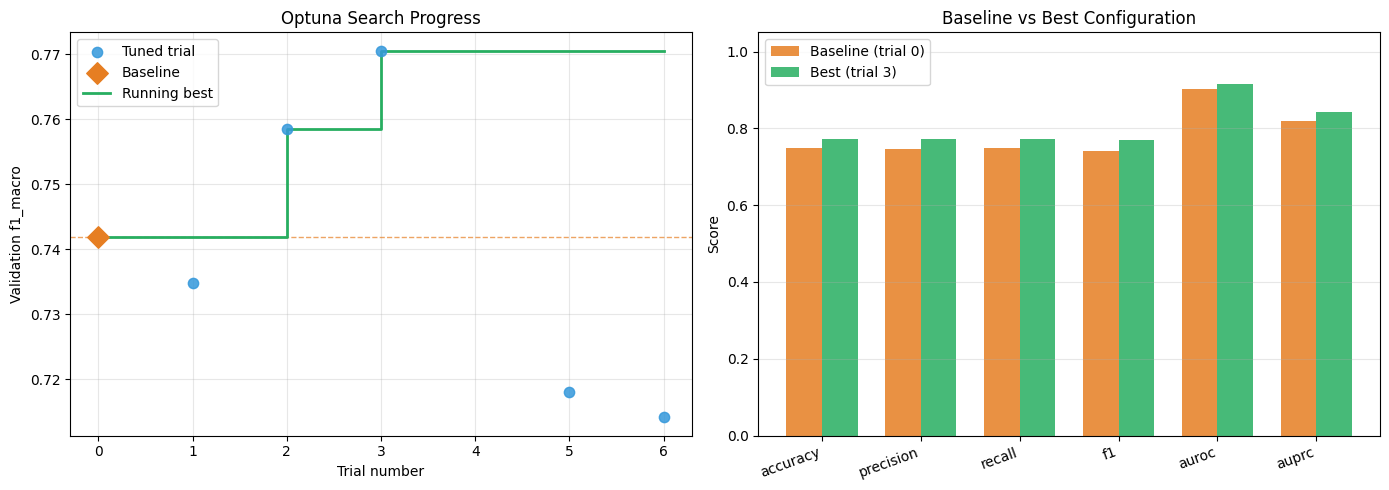

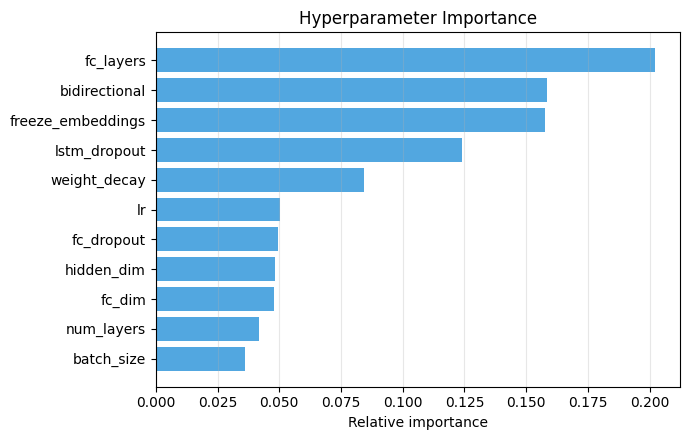

In [ ]:
# Plot trial results: search progress and a baseline-vs-best metric comparison.
obj = OBJECTIVE_METRIC
df = trials_df.sort_values('trial')
base_mask = df['is_baseline']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: objective per trial with the running best as a step line.
axes[0].scatter(df.loc[~base_mask, 'trial'], df.loc[~base_mask, obj],
                s=55, color='#3498db', alpha=0.85, label='Tuned trial', zorder=3)
if base_mask.any():
    axes[0].scatter(df.loc[base_mask, 'trial'], df.loc[base_mask, obj],
                    s=120, marker='D', color='#e67e22', label='Baseline', zorder=5)
    axes[0].axhline(df.loc[base_mask, obj].iloc[0], ls='--', lw=1,
                    color='#e67e22', alpha=0.7)
axes[0].step(df['trial'], df[obj].cummax(), where='post',
             color='#27ae60', lw=2, label='Running best')
axes[0].set_xlabel('Trial number'); axes[0].set_ylabel(f'Validation {obj}')
axes[0].set_title('Optuna Search Progress')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: relative importance of each hyperparameter.
try:
    importance = optuna.importance.get_param_importances(study)
    names = list(importance)[::-1]
    axes[1].barh(names, [importance[n] for n in names], color='#3498db', alpha=0.85)
    axes[1].set_xlabel('Relative importance')
    axes[1].set_title('Hyperparameter Importance')
    axes[1].grid(axis='x', alpha=0.3)
except Exception as e:
    axes[1].set_title(f'(importance unavailable: {e})')

plt.tight_layout(); plt.show()

In [ ]:
%%time

# final training on the 80% TRAIN + VAL split, then evaluate on the 20% TEST split.

if USE_STUDY_BEST and 'study' in globals():
    fit_config = {**BASELINE_CONFIG, **study.best_params}
else:
    fit_config = dict(FINAL_CONFIG)

model_label = 'LSTM (baseline)' if fit_config == BASELINE_CONFIG else 'LSTM (tuned)'
print(f"Fitting {model_label} with: {fit_config}")

set_seed()
model = CustomLSTM.from_config(fit_config, embedding_matrix, OUTPUT_DIM).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=fit_config['lr'],
                        weight_decay=fit_config['weight_decay'])

fit_train_loader = make_loader(X_train_tensors, y_train_tensor,
                               batch_size=fit_config['batch_size'], shuffle=True)
fit_val_loader = make_loader(X_val_tensors, y_val_tensor,
                             batch_size=fit_config['batch_size'])

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc, best_state = -1.0, None

for epoch in range(EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = train_model(model, fit_train_loader, criterion, optimizer,
                                  device, log_every=0)
    va_loss, va_acc, _, _ = evaluate_model(model, fit_val_loader, criterion, device)

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        marker = '  <- best so far'
    else:
        marker = ''
    print(f"Epoch {epoch+1}/{EPOCHS} | Train {tr_loss:.4f}/{tr_acc:.4f} | "
          f"Val {va_loss:.4f}/{va_acc:.4f} | {time.time()-t0:.1f}s{marker}")

# Restore the best-validation weights rather than reporting the last epoch.
model.load_state_dict(best_state)
torch.save(best_state, 'lstm_best_model.pt')
print(f"\nRestored epoch with best validation accuracy: {best_val_acc:.4f}")

# Evaluation on held-out test set
test_probs, test_labels = au.collect_probs_lstm(model, test_loader, device)
test_preds = test_probs.argmax(1)
print(f"Test set scored: {len(test_labels):,} rows")

Fitting LSTM (tuned) with: {'lr': 0.004084, 'weight_decay': 2e-05, 'hidden_dim': 128, 'num_layers': 2, 'bidirectional': True, 'lstm_dropout': 0.259646, 'fc_layers': 2, 'fc_dim': 64, 'fc_dropout': 0.190272, 'batch_size': 256, 'freeze_embeddings': True}
Epoch 1/10 | Train 0.8719/0.5763 | Val 0.6932/0.6777 | 1339.6s  <- best so far
Epoch 2/10 | Train 0.6445/0.7160 | Val 0.5755/0.7408 | 1238.6s  <- best so far
Epoch 3/10 | Train 0.5740/0.7518 | Val 0.5734/0.7458 | 1278.1s  <- best so far
Epoch 4/10 | Train 0.5342/0.7723 | Val 0.5254/0.7724 | 1254.1s  <- best so far
Epoch 5/10 | Train 0.4950/0.7913 | Val 0.5072/0.7846 | 1272.5s  <- best so far
Epoch 6/10 | Train 0.4717/0.8012 | Val 0.5434/0.7721 | 1376.3s
Epoch 7/10 | Train 0.4479/0.8127 | Val 0.5072/0.7853 | 1122.1s  <- best so far
Epoch 8/10 | Train 0.4182/0.8262 | Val 0.5167/0.7864 | 1102.3s  <- best so far
Epoch 9/10 | Train 0.3942/0.8374 | Val 0.5301/0.7805 | 1119.2s
Epoch 10/10 | Train 0.3705/0.8501 | Val 0.5483/0.7855 | 1201.4s

Rest

# Step 4 — Model Evaluation

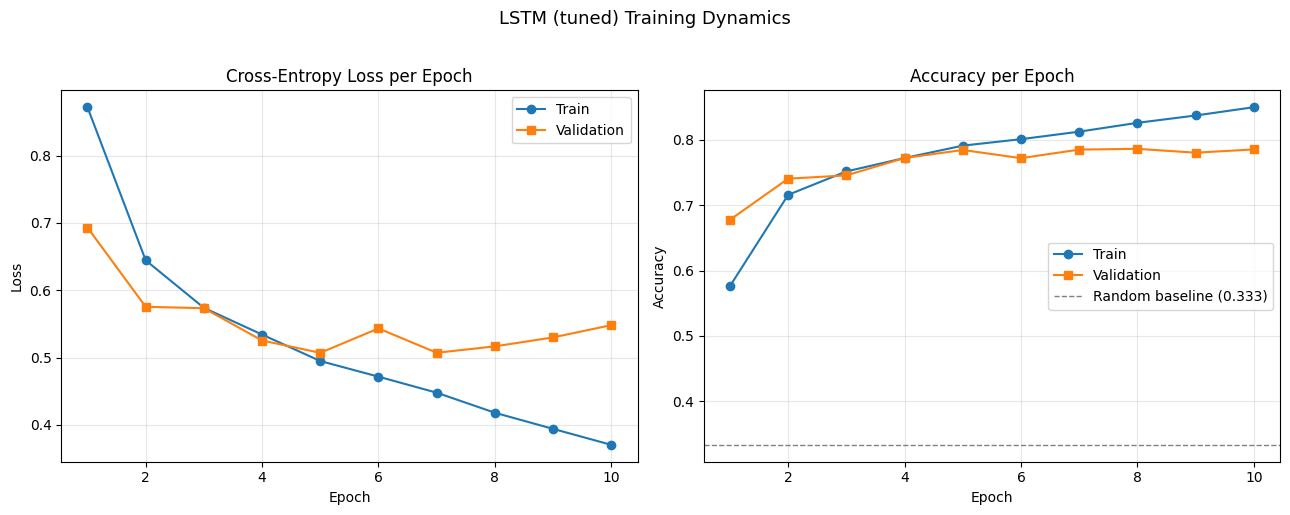

Final train acc 0.8501 | validation acc 0.7855 | gap +0.0646
Best validation acc: 0.7864 at epoch 8

===== LSTM (tuned): Test-Set Metrics =====
Accuracy : 0.7840
AUROC    : 0.9241 (macro, one-vs-rest)
AUPRC    : 0.8564 (macro)

              precision  recall  f1-score  support
Negative         0.8685  0.7454    0.8022     6767
Neutral          0.6611  0.7641    0.7089     6656
Positive         0.8538  0.8437    0.8487     6577
macro avg        0.7945  0.7844    0.7866    20000
weighted avg     0.7946  0.7840    0.7865    20000

===== LSTM (tuned): Confusion =====


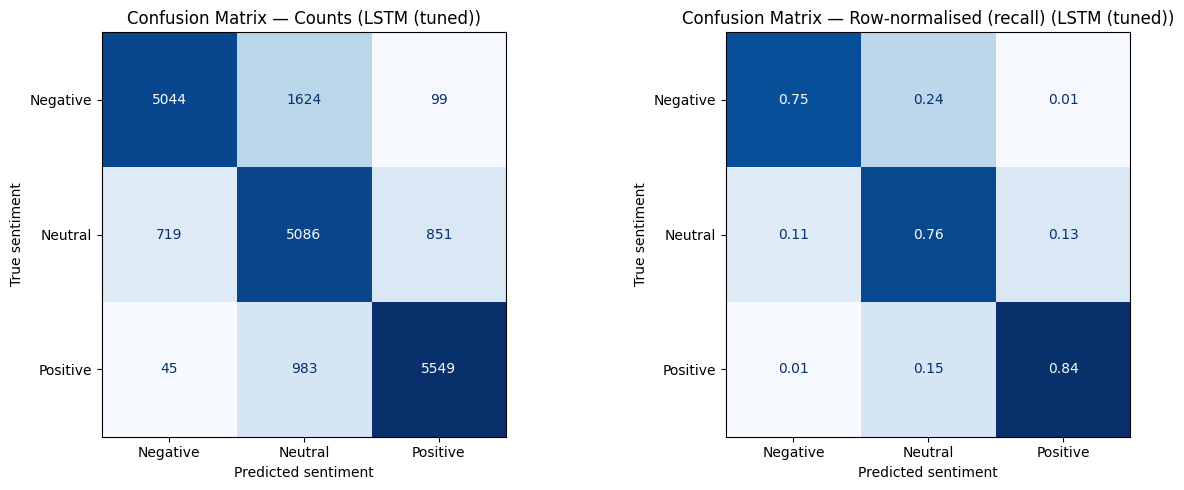

Negative: recall 0.745 | most common error -> Neutral (0.240)
Neutral : recall 0.764 | most common error -> Positive (0.128)
Positive: recall 0.844 | most common error -> Neutral (0.149)


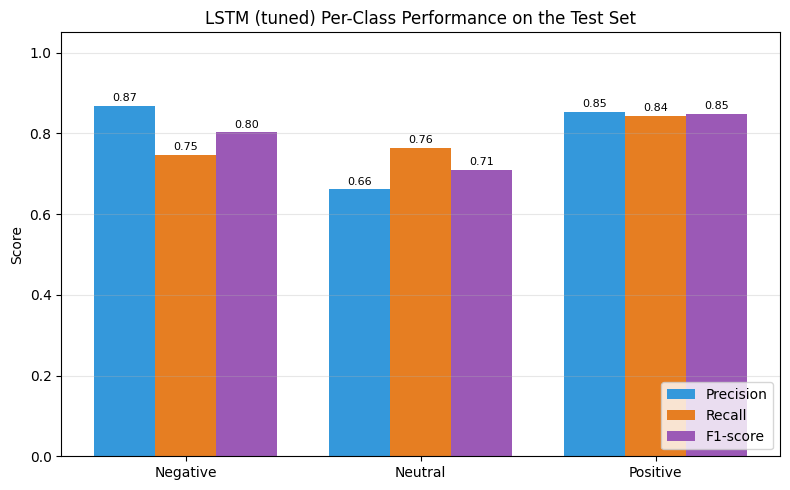

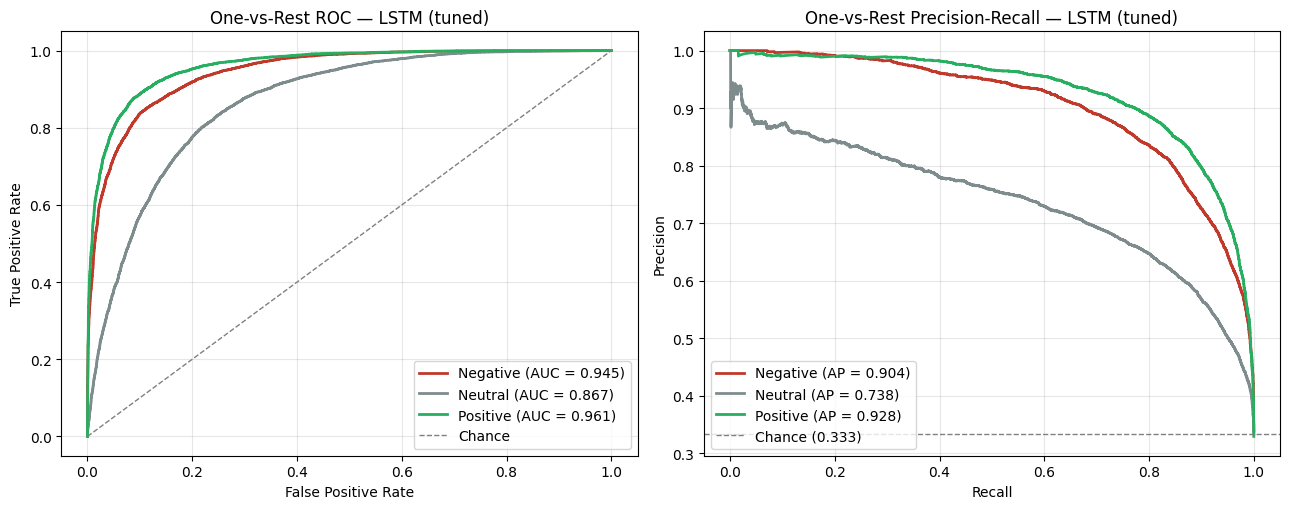


===== LSTM (tuned): Confidence =====


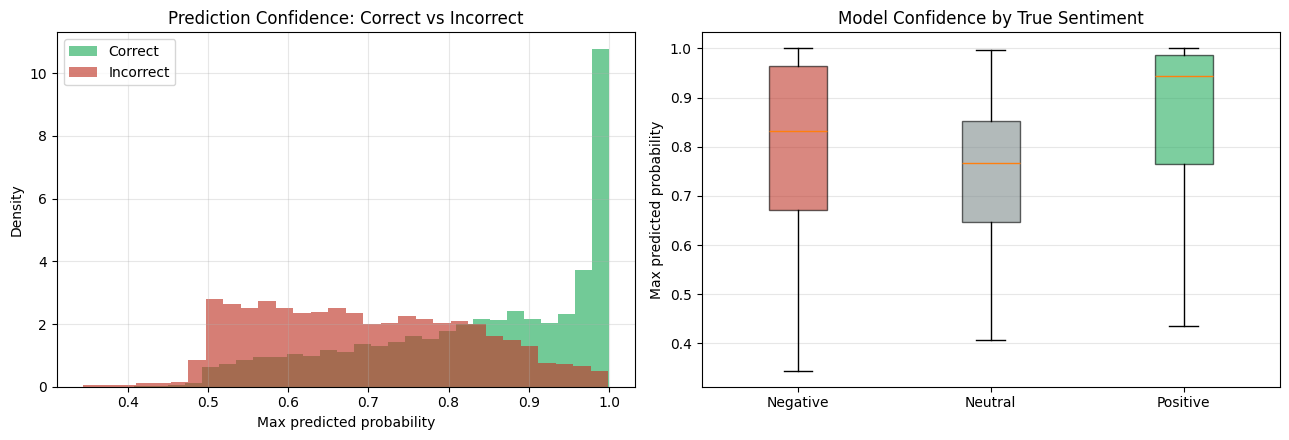

,precision,recall,f1-score,support
Negative,0.8685,0.7454,0.8022,6767
Neutral,0.6611,0.7641,0.7089,6656
Positive,0.8538,0.8437,0.8487,6577
macro avg,0.7945,0.7844,0.7866,20000
weighted avg,0.7946,0.7840,0.7865,20000


,True class,Mean confidence,Mean confidence (correct),Mean confidence (incorrect)
0,Negative,0.8056,0.8439,0.6933
1,Neutral,0.7470,0.7605,0.7033
2,Positive,0.8668,0.9015,0.6791


In [ ]:
# One call produces: training curves, metrics table, both confusion matrices,
# per-class bars, ROC + PR curves, and the confidence analysis.
metrics_df, test_summary = au.full_evaluation_report(
    test_labels, test_preds,
    history=history,
    model_label=model_label,
    save_csv='lstm_test_metrics.csv',
)

display(metrics_df)

In [ ]:
# Final comparison of the baseline, tuned, and held-out test metrics.
if 'trials_df' not in globals():
    trials_df = pd.read_csv('lstm_hpo_trials.csv')

baseline_cv = trials_df[trials_df['is_baseline']].iloc[0]
best_cv = trials_df.loc[trials_df[OBJECTIVE_METRIC].idxmax()]

comparison = pd.DataFrame({
    'Baseline (validation)': [f"{baseline_cv[m]:.4f}" for m in au.METRIC_KEYS],
    'Tuned (validation)':    [f"{best_cv[m]:.4f}" for m in au.METRIC_KEYS],
    f'{model_label} (held-out test)': [f"{test_summary[m]:.4f}" for m in au.METRIC_KEYS],
}, index=au.METRIC_KEYS)

print("Final comparison — the test column was computed exactly once:")
display(comparison)
comparison.to_csv('lstm_final_comparison.csv')

Final comparison — the test column was computed exactly once:


,Baseline (validation),Tuned (validation),LSTM (tuned) (held-out test)
accuracy,0.7485,0.7721,0.7840
precision_macro,0.7461,0.7725,0.7945
recall_macro,0.7485,0.7713,0.7844
f1_macro,0.7419,0.7706,0.7866
auroc_macro,0.9037,0.9151,0.9241
auprc_macro,0.8188,0.8430,0.8564


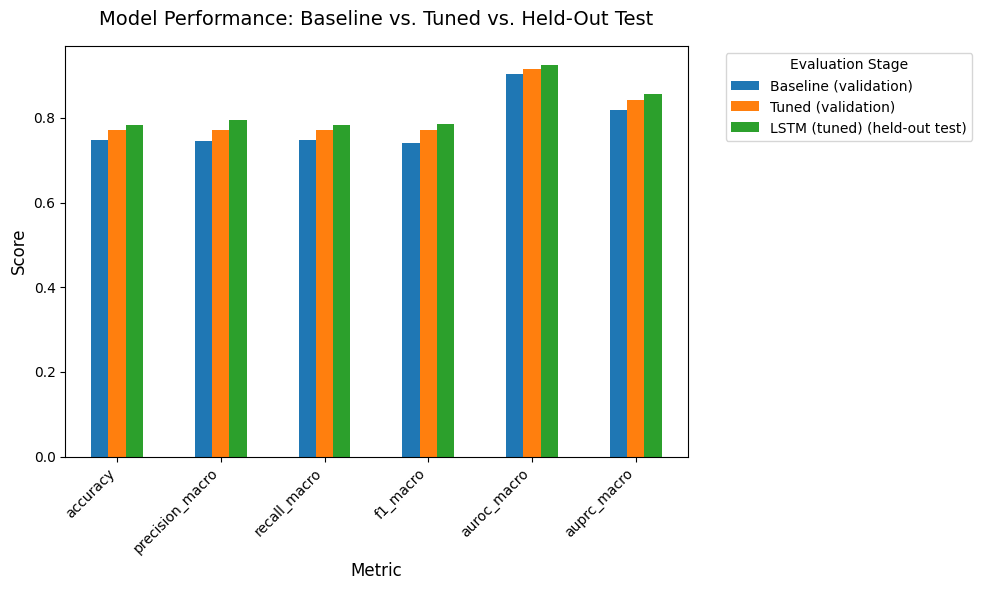

In [67]:
# Convert to float for plotting
plot_df = comparison.astype(float)

# Create the grouped bar chart
ax = plot_df.plot(kind='bar', figsize=(10, 6))

# Add info
plt.title('Model Performance: Baseline vs. Tuned vs. Held-Out Test', fontsize=14, pad=15)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Evaluation Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

# Step 5 — Vocabulary Analysis (Bag of Words + Word Cloud)

In [ ]:
# Build the document-term matrix and aggregate it per sentiment class.
stop_words = au.make_stopword_list()

bow = au.build_class_bow(X_train_tokens, y_train_arr,
                         max_tokens=MAX_LENGTH, stop_words=stop_words,
                         min_df=10, max_features=VOCAB_SIZE)

for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<8}: {bow['class_counts'][i].sum():,} tokens across "
          f"{(y_train_arr == CLASS_IDS[i]).sum():,} reviews")

# Confirm the negation tokens survived into the analysis vocabulary.
vocab_set = set(bow['vocab'])
print("\nNegation tokens present in BoW vocab:",
      {w: (w in vocab_set) for w in ['not', 'no', 'never', 'but', 'nothing']})

sklearn stop words       : 318
Sentiment tokens rescued : 22 -> ['again', 'against', 'although', 'but', 'cannot', 'enough', 'however', 'least', 'less', 'never', 'no', 'none', 'nor', 'not', 'nothing', 'nowhere', 'off', 'only', 'though', 'too', 'very', 'without']
Final stop-word list     : 296
Documents: 72,000 | Vocabulary: 10,000 | Density: 0.3914%
Total tokens counted: 3,343,127
  Negative: 1,169,157 tokens across 23,856 reviews
  Neutral : 1,219,344 tokens across 23,966 reviews
  Positive: 954,626 tokens across 24,178 reviews

Negation tokens present in BoW vocab: {'not': True, 'no': True, 'never': True, 'but': True, 'nothing': True}


Top 20 most frequent words per sentiment (raw counts):
Words appearing in ALL 3 top-20 lists: 10/20 -> ['but', 'food', 'good', 'just', 'like', 'not', 'place', 'service', 'time', 'very']


,Negative,Neutral,Positive
#1,"not (47,352)","not (42,396)","not (20,488)"
#2,"but (20,717)","but (30,979)","but (15,302)"
#3,"food (18,091)","good (19,394)","food (14,739)"
#4,"place (10,490)","food (18,253)","great (13,338)"
#5,"no (9,703)","place (11,950)","good (12,627)"
#6,"did (9,550)","very (10,688)","place (11,563)"
#7,"just (9,353)","just (10,049)","very (9,598)"
#8,"service (9,179)","like (9,744)","service (7,390)"
#9,"good (8,917)","service (8,828)","time (5,966)"
#10,"like (8,887)","did (8,278)","delicious (5,909)"


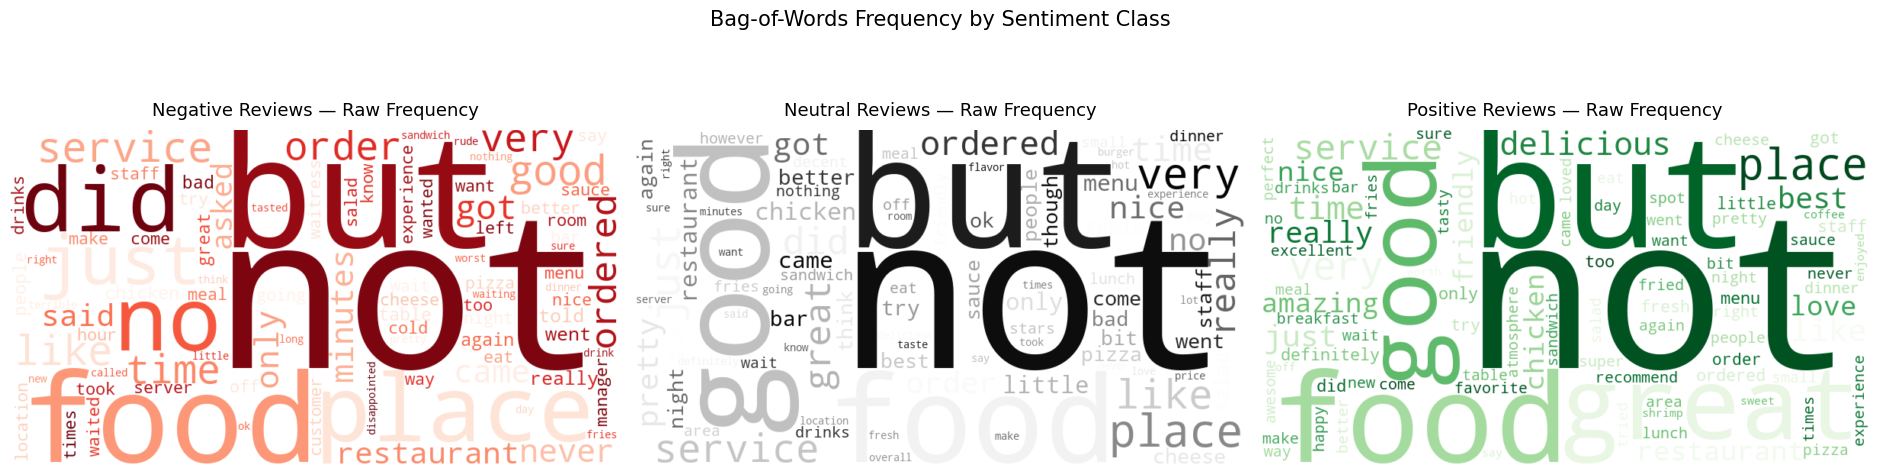

In [58]:
# Frequency analysis of the bag-of-words representation, per sentiment class.
print("Top 20 most frequent words per sentiment (raw counts):")
display(au.top_words_table(bow, bow['class_counts'], top_n=20, label='count'))

au.plot_wordclouds(bow, bow['class_counts'], subtitle='Raw Frequency',
                   random_state=RAND_STATE,
                   suptitle='Bag-of-Words Frequency by Sentiment Class')

Top 20 most DISTINCTIVE words per sentiment (log-odds z-score):
Words appearing in ALL 3 top-20 lists: 0/20 -> []


,Negative,Neutral,Positive
#1,not (57.3),but (53.3),great (83.7)
#2,no (53.7),good (46.0),delicious (72.0)
#3,told (52.4),pretty (37.5),amazing (62.7)
#4,minutes (52.3),ok (32.9),best (53.1)
#5,asked (47.2),bit (30.0),love (47.9)
#6,manager (46.6),decent (29.9),definitely (45.8)
#7,never (44.4),average (26.9),friendly (44.7)
#8,said (43.9),overall (25.3),perfect (44.0)
#9,worst (42.1),little (23.5),favorite (42.5)
#10,rude (40.9),however (22.9),awesome (42.4)


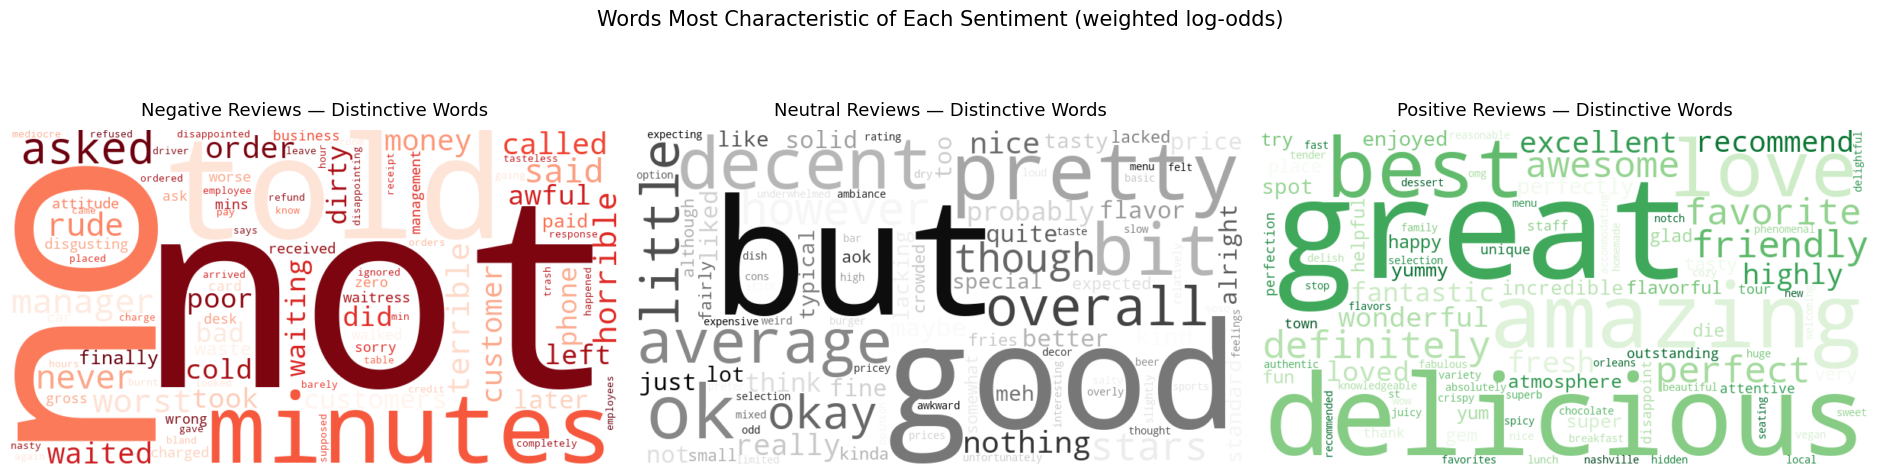

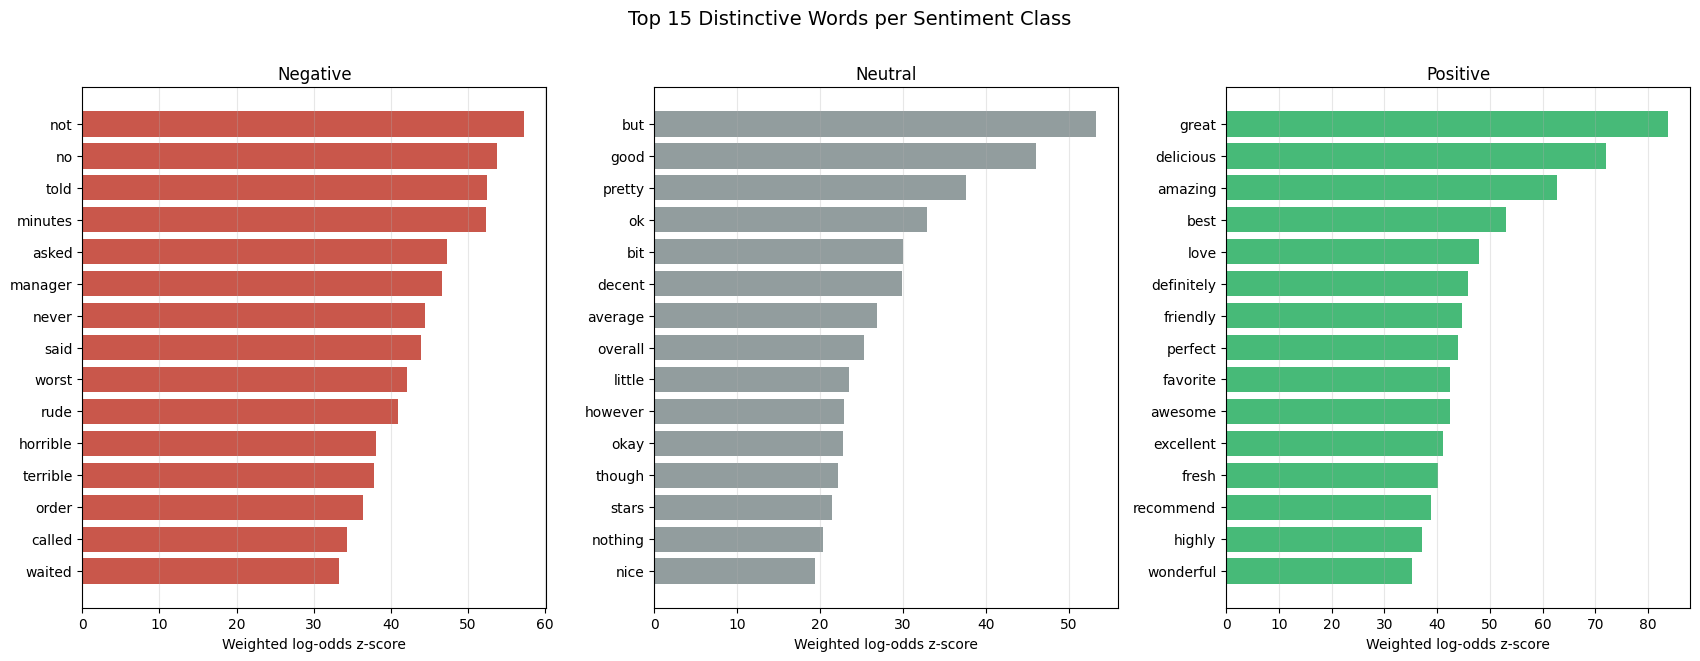

In [59]:
# Analyze the most distinctive words per sentiment class using weighted log-odds with an informative Dirichlet prior.
# This method identifies words that are more characteristic of one sentiment class compared to others
zscores = au.compute_zscores(bow)

print("Top 20 most DISTINCTIVE words per sentiment (log-odds z-score):")
display(au.top_words_table(bow, zscores, top_n=20, label='score'))

au.plot_wordclouds(bow, zscores, subtitle='Distinctive Words',
                   random_state=RAND_STATE,
                   suptitle='Words Most Characteristic of Each Sentiment (weighted log-odds)')

au.plot_distinctive_words(bow, zscores, k=15)

# Step 5 — LIME Interpretability (3-class)

In [61]:
# LSTM-specific wrapper for LIME
lstm_predict_proba = au.make_lstm_predict_proba(
    model=model, device=device,
    clean_and_tokenize=clean_and_tokenize,
    encode_and_truncate=encode_and_truncate,
    word2idx=word2idx, max_length=MAX_LENGTH)

explainer = au.make_lime_explainer(random_state=RAND_STATE)

# Use clean, truncated, and tokenized text for the LIME wrapper
def model_view(text):
    return ' '.join(clean_and_tokenize(text)[:MAX_LENGTH])

# Sanity check: the wrapper must reproduce the stored test predictions.
X_test_list = list(X_test)
probe = lstm_predict_proba(X_test_list[:200])
agreement = (probe.argmax(1) == test_preds[:200]).mean()
print(f"Wrapper shape {probe.shape} | rows sum to 1: {np.allclose(probe.sum(1), 1)}")
print(f"Agreement with stored test_preds on first 200: {agreement:.4f}")
assert agreement > 0.99, "predict_proba has drifted from the evaluation path"

Wrapper shape (200, 3) | rows sum to 1: True
Agreement with stored test_preds on first 200: 1.0000


TRUE = Negative  (test row 21)
Work close by, so I decided to try it and get a togo breakfast burrito. The only thing tasty was the packaged cold tortilla. Since I couldn't find the eggs in it. The potatoes were old and the black beans had to be out of a can with huge cut pieces of scallions. I won't be back. ...



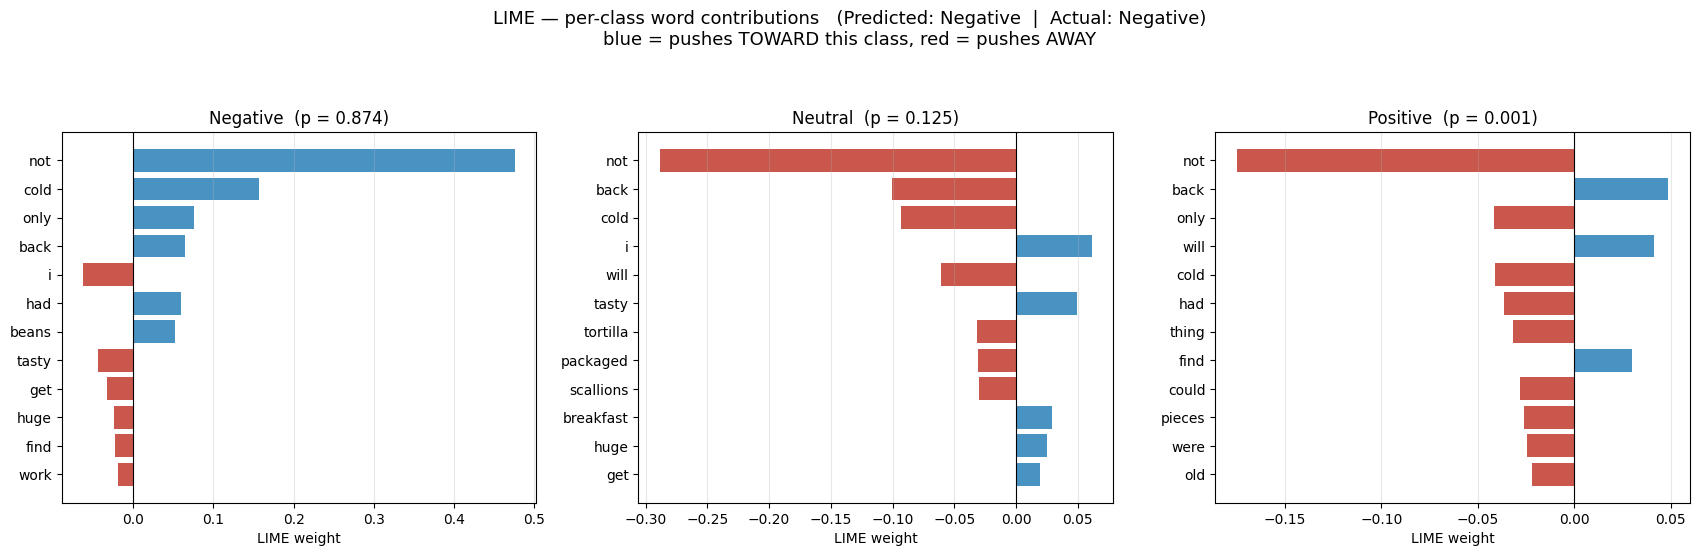

TRUE = Neutral  (test row 4)
The Buddhas feast was ok - nothing really special.  Meat was a bit chewy for "filet mignon".  Husband had Drunken with chicken which tasted great.  Will have that next time and skip the beef. ...



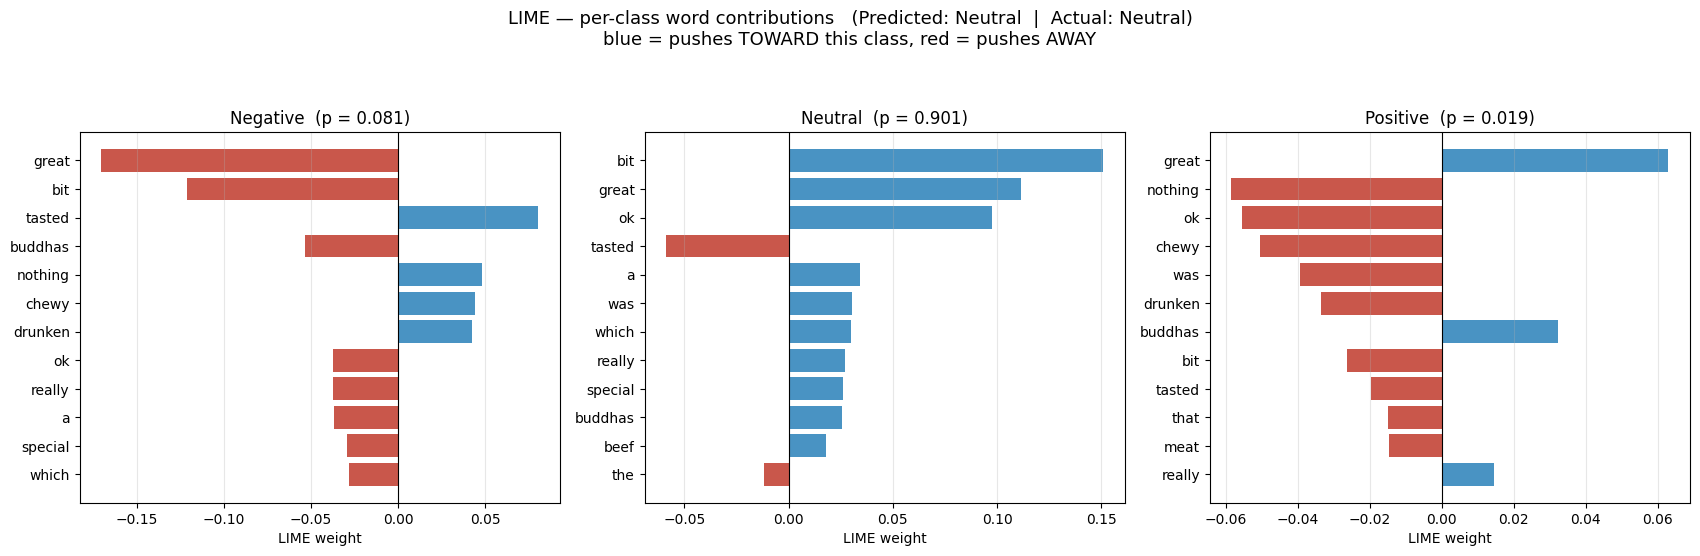

TRUE = Positive  (test row 0)
This is the finest in NOLA breakfast foods. We stumbled upon this gem while just wandering to find food. I uploaded some photos to prove my rating on here. Just order anything and you won't go wrong! ...



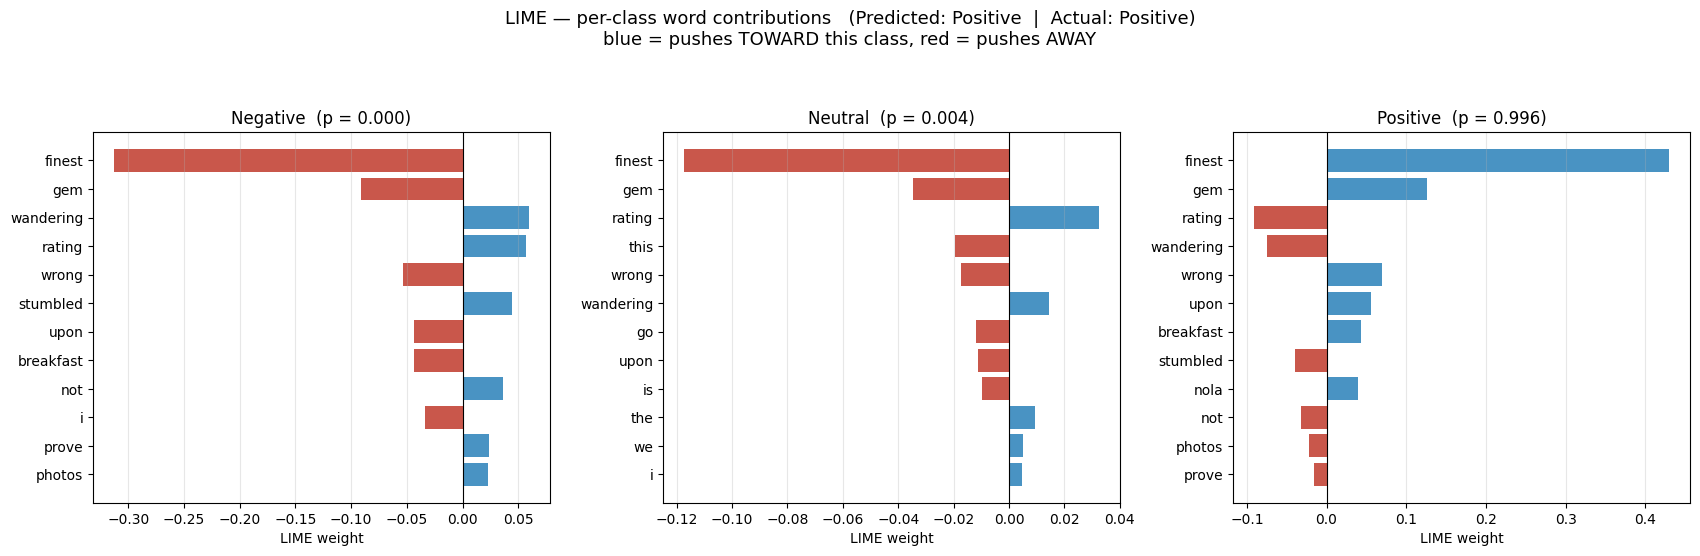

In [62]:
# Demonstrate one LIME explanation per sentiment class
tok_len = np.array([len(t) for t in X_test_tokens])

lime_examples = {}
for c in CLASS_IDS:
    cand = np.where((y_test_arr == c) & (test_preds == c) &
                    (tok_len > 25) & (tok_len < 70))[0]
    idx = int(cand[0]) if len(cand) else int(np.where(y_test_arr == c)[0][0])

    print("=" * 100)
    print(f"TRUE = {CLASS_NAMES[c]}  (test row {idx})")
    print(X_test_list[idx][:400], "...\n")
    lime_examples[c] = au.plot_lime_instance(
        X_test_list[idx], lstm_predict_proba, explainer,
        model_view=model_view, true_id=c)

In [63]:
%%time

# Aggregate LIME explanations across the test set, per sentiment class.
# This helps identify which words are most influential for the model's predictions in each class.
lime_df = au.run_lime_batch(
    X_test_list, y_test_arr, lstm_predict_proba, explainer,
    model_view=model_view,
    n_per_class=N_PER_CLASS, num_samples=NUM_SAMPLES, num_features=NUM_FEATURES,
    random_state=RAND_STATE, save_csv='lime_word_weights_raw.csv')

influence, obs_count, lime_agg = au.aggregate_lime(lime_df, min_obs=MIN_OBS)

Explaining 90 reviews x 800 perturbations = 72,000 forward passes...
  10/90 reviews  (0.61/s, ~2.2 min left)
  20/90 reviews  (0.73/s, ~1.6 min left)
  30/90 reviews  (0.80/s, ~1.3 min left)
  40/90 reviews  (0.83/s, ~1.0 min left)
  50/90 reviews  (0.81/s, ~0.8 min left)
  60/90 reviews  (0.78/s, ~0.6 min left)
  70/90 reviews  (0.79/s, ~0.4 min left)
  80/90 reviews  (0.81/s, ~0.2 min left)
  90/90 reviews  (0.83/s, ~0.0 min left)

Done in 1.8 min. 6,651 (word, class) weights over 1,316 unique words.
Words retained (seen in >= 5 explanations for every class): 62

Pushes most strongly TOWARD Negative:
  no (+0.127), bad (+0.090), not (+0.082), if (+0.036), ordered (+0.031), do (+0.030), had (+0.024), they (+0.024), at (+0.022), food (+0.020), service (+0.018), would (+0.016)

Pushes most strongly TOWARD Neutral:
  but (+0.090), ok (+0.070), pretty (+0.050), was (+0.047), nice (+0.040), good (+0.038), chicken (+0.035), were (+0.030), its (+0.026), that (+0.025), i (+0.022), service (+

# Step 6 — Visualisation and Reporting

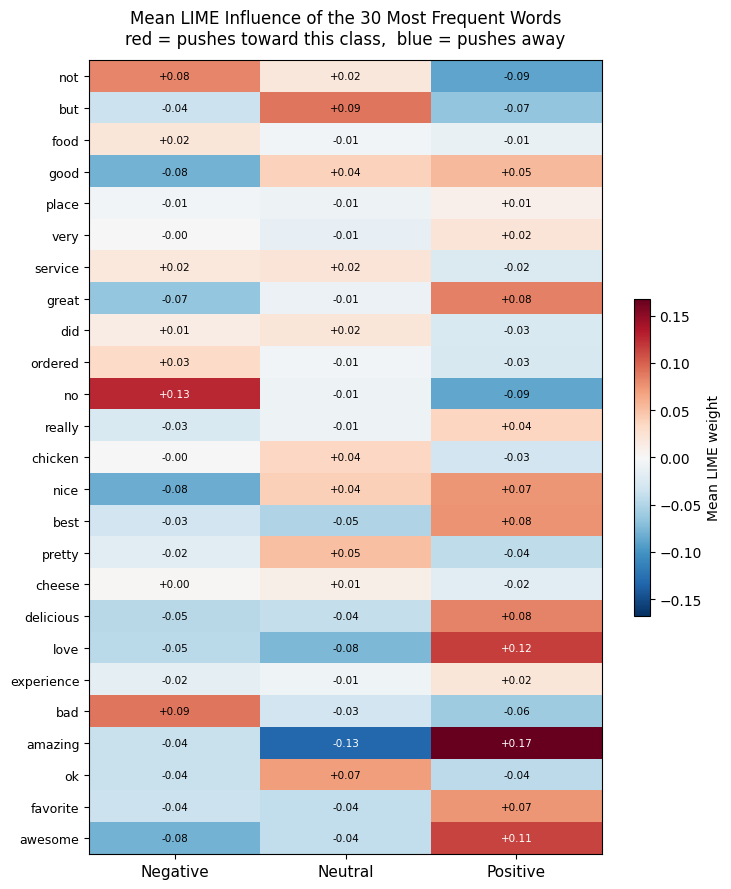

class,Negative,Neutral,Positive
word,,,
not,0.0820,0.0190,-0.0884
but,-0.0357,0.0898,-0.0662
food,0.0199,-0.0052,-0.0129
good,-0.0789,0.0381,0.0542
place,-0.0050,-0.0084,0.0090
very,-0.0013,-0.0142,0.0220
service,0.0179,0.0213,-0.0247
great,-0.0652,-0.0098,0.0844
did,0.0128,0.0207,-0.0252


In [64]:
# Influence heatmap for the highest-frequency BoW words
heat = au.plot_influence_heatmap(influence, bow, top_freq=30,
                                 save_csv='lime_influence_top_frequent_words.csv')
display(heat.round(4))